In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SUBJECTS = ["Maths", "Physics", "Chemistry", "English", "Computer Science"]
PASS_MARK = 40

In [2]:
np.random.seed(42)
names = [f"Student {i}" for i in range(1, 31)]
marks = np.random.randint(30, 100, size=(30, len(SUBJECTS)))

data = pd.DataFrame(marks, columns=SUBJECTS)
data.insert(0, "Name", names)
data.to_csv("marks.csv", index=False)
data.head()

,Name,Maths,Physics,Chemistry,English,Computer Science
0,Student 1,81,44,90,50,53
1,Student 2,32,51,82,31,59
2,Student 3,67,31,93,89,50
3,Student 4,62,87,51,78,88
4,Student 5,71,89,44,91,91


In [3]:
df = pd.read_csv("marks.csv")
print("Missing values:", df.isnull().sum().sum())

df["Total"] = df[SUBJECTS].sum(axis=1)
df["Average"] = df[SUBJECTS].mean(axis=1).round(2)
df["Result"] = np.where((df[SUBJECTS] >= PASS_MARK).all(axis=1), "Pass", "Fail")
df["Rank"] = df["Total"].rank(ascending=False, method="min").astype(int)
df.head()

Missing values: 0


,Name,Maths,Physics,Chemistry,English,Computer Science,Total,Average,Result,Rank
0,Student 1,81,44,90,50,53,318,63.6,Pass,16
1,Student 2,32,51,82,31,59,255,51.0,Fail,27
2,Student 3,67,31,93,89,50,330,66.0,Fail,14
3,Student 4,62,87,51,78,88,366,73.2,Pass,4
4,Student 5,71,89,44,91,91,386,77.2,Pass,2


In [4]:
print("Top 5 students:")
display(df.sort_values("Rank").head(5)[["Name", "Total", "Average", "Rank"]])

print("Subject-wise average marks:")
display(df[SUBJECTS].mean().round(2))

print("Subject toppers:")
for subject in SUBJECTS:
    top = df.loc[df[subject].idxmax()]
    print(f"{subject}: {top['Name']} ({top[subject]})")

pass_percentage = (df["Result"] == "Pass").mean() * 100
print(f"\nPass percentage: {pass_percentage:.1f}%")

Top 5 students:


,Name,Total,Average,Rank
5,Student 6,424,84.8,1
4,Student 5,386,77.2,2
29,Student 30,381,76.2,3
3,Student 4,366,73.2,4
11,Student 12,366,73.2,4


Subject-wise average marks:


Maths               63.40
Physics             58.30
Chemistry           70.53
English             66.77
Computer Science    59.87
dtype: float64

Subject toppers:
Maths: Student 28 (99)
Physics: Student 20 (94)
Chemistry: Student 3 (93)
English: Student 15 (94)
Computer Science: Student 24 (95)

Pass percentage: 43.3%


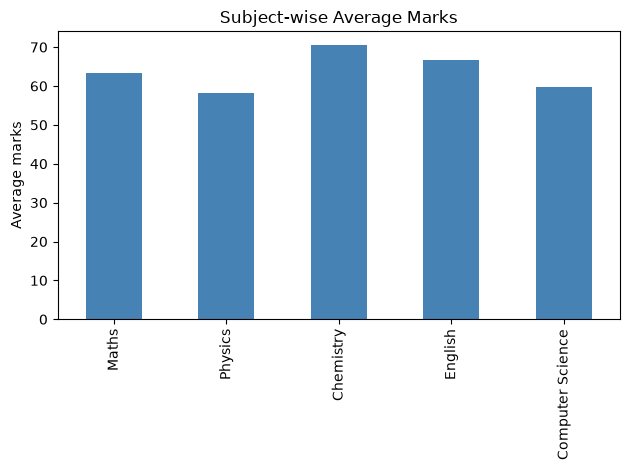

In [5]:
df[SUBJECTS].mean().plot(kind="bar", color="steelblue")
plt.title("Subject-wise Average Marks")
plt.ylabel("Average marks")
plt.tight_layout()
plt.savefig("subject_averages.png")
plt.show()

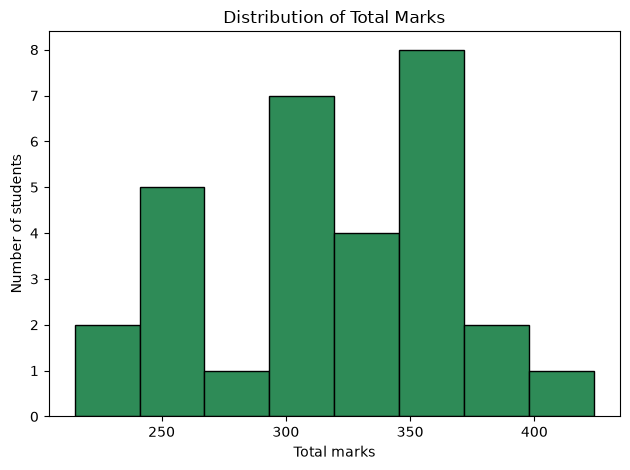

In [6]:
plt.hist(df["Total"], bins=8, color="seagreen", edgecolor="black")
plt.title("Distribution of Total Marks")
plt.xlabel("Total marks")
plt.ylabel("Number of students")
plt.tight_layout()
plt.savefig("total_distribution.png")
plt.show()

In [7]:
df.sort_values("Rank").to_csv("results.csv", index=False)
print("Saved results.csv")

Saved results.csv
